In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import random

The saturation vapor pressure equation

In [ ]:
def y(x):
    return 6.112 * torch.exp((17.67 * x) / (x + 243.5))

Use NN to fit equation

In [49]:
class QuadraticNet(nn.Module):
    def __init__(self):
        super(QuadraticNet, self).__init__()

        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.Tanh(),

            nn.Linear(64, 64),
            nn.Tanh(),

            nn.Linear(64, 32),
            nn.Tanh(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)

model = QuadraticNet()
print(model)

QuadraticNet(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): Tanh()
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [50]:
x = torch.tensor(
    np.random.uniform(-20, 40, 10000),
    dtype=torch.float32
).unsqueeze(1)

y_true = y(x)

In [51]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

epochs = 2000

for epoch in range(epochs):
    optimizer.zero_grad()
    y_pred = model(x)
    loss = criterion(y_pred, y_true)
    loss.backward()
    optimizer.step()

    if epoch % 200 == 0:
        print(f"Epoch {epoch}, Loss = {loss.item():.6f}")

Epoch 0, Loss = 768.140198
Epoch 200, Loss = 37.280560
Epoch 400, Loss = 5.823370
Epoch 600, Loss = 1.276207
Epoch 800, Loss = 0.431260
Epoch 1000, Loss = 0.413122
Epoch 1200, Loss = 0.084585
Epoch 1400, Loss = 0.083138
Epoch 1600, Loss = 0.035792
Epoch 1800, Loss = 0.461733


In [52]:
test_x = torch.tensor([[15.0]])
pred_y = model(test_x)

true_y = y(test_x)

print("\nTest result:")
print("Predicted y =", pred_y.item())
print("True y      =", true_y)


Test result:
Predicted y = 16.92024803161621
True y      = tensor([[17.0405]])


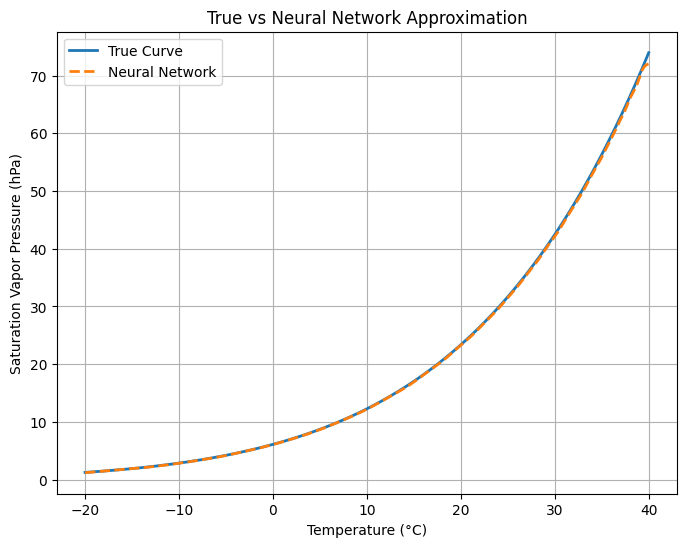

In [ ]:
# Test data
x_plot = torch.tensor(
    np.linspace(-20, 40, 500),
    dtype=torch.float32
).unsqueeze(1)

# True curve
y_true_plot = y(x_plot)

# NN model predictions
model.eval()
with torch.no_grad():
    y_pred_plot = model(x_plot)

plt.figure(figsize=(8,6))

plt.plot(
    x_plot.numpy(),
    y_true_plot.numpy(),
    label="True Curve",
    linewidth=2
)

plt.plot(
    x_plot.numpy(),
    y_pred_plot.numpy(),
    label="Neural Network",
    linestyle="--",
    linewidth=2
)

plt.xlabel("Temperature (°C)")
plt.ylabel("Saturation Vapor Pressure (hPa)")
plt.title("True vs Neural Network Approximation")
plt.legend()
plt.grid(True)

plt.show()

Use symtorch to interpret NN

In [ ]:
from symtorch import SymbolicModel   


model_sr0 = SymbolicModel(model, "distilled_saturation_pressure")

num_data = 10000

sample_data = torch.tensor(
    np.random.uniform(-40, 40, (num_data, 1)),  # whole physical range
    dtype=torch.float32
)

sr_params = {
    "niterations": 200,        
                  
    "complexity_of_constants":1,
    'maxsize': 30,
    "binary_operators": ["+", "-", "*", "/"],
    "unary_operators": ["exp"],
    'elementwise_loss':"loss(prediction, target) = abs(prediction - target)",
    "parsimony": 0.001,         
    "batching":True,
    "random_state": 42,
    
}

fit_params = {
    "variable_names": ["x"]
}

model_sr0.distill(
    sample_data,
    sr_params=sr_params,
    fit_params=fit_params
)

d:\anaconda3\envs\torch_sym\Lib\site-packages\pysr\sr.py:2811: UserWarning: Note: it looks like you are running in Jupyter. The progress bar will be turned off.
  warnings.warn(
d:\anaconda3\envs\torch_sym\Lib\site-packages\pysr\sr.py:1873: UserWarning: Note: Setting `random_state` without also setting `deterministic=True` and `parallelism='serial'` will result in non-deterministic searches.
  warnings.warn(
[ Info: Started!



Expressions evaluated per second: 7.380e+03
Progress: 884 / 6200 total iterations (14.258%)
════════════════════════════════════════════════════════════════════════════════════════════════════
───────────────────────────────────────────────────────────────────────────────────────────────────
Complexity  Loss       Score      Equation
1           1.356e+01  0.000e+00  y = 6.0308
3           9.289e+00  1.891e-01  y = x + 12.357
5           6.825e+00  1.541e-01  y = (x + 22.418) * 0.54794
6           5.964e+00  1.348e-01  y = exp(x * 0.11372)
7           4.083e+00  3.789e-01  y = ((x * 0.02267) + 0.74563) * x
8           1.049e+00  1.359e+00  y = 6.195 / exp(x * -0.064116)
10          3.108e-01  6.081e-01  y = (8.5218 / exp(x / -18.228)) - 2.3117
13          3.091e-01  1.787e-03  y = (8.5218 / exp(x / -18.228)) - exp(0.81393)
17          3.090e-01  9.404e-05  y = ((8.5218 / exp(x / -18.228)) - exp(0.81393 / 0.7519)) ...
                                      + 0.68994
23          2.793e-0

[ Info: Final population:
[ Info: Results saved to:


{0: PySRRegressor.equations_ = [
 	    pick     score                                           equation  \
 	0         0.000000                                            6.03384   
 	1         0.189122                                      x + 12.472445   
 	2         0.154296                        (x + 21.855595) * 0.5540137   
 	3         0.135143                                exp(x * 0.11423797)   
 	4         0.388017                 x * ((x * 0.02373959) + 0.7180217)   
 	5         1.473767                   6.6196165 / exp(x * -0.06123623)   
 	6         0.548929         (8.521765 / exp(x / -18.22795)) - 2.265931   
 	7         0.025273  ((9.384249 / exp(x * -0.052679293)) + (-0.2846...   
 	8         0.002387  ((9.384249 / exp(x * -0.052679293)) + exp(exp(...   
 	9   >>>>  0.189261  (9.384249 / exp(-0.052679293 * x)) + ((-0.3692...   
 	10        0.017621  (-0.36928818 / (-0.2846809 - exp(x * 0.2427329...   
 	11        0.001835  (-0.36928818 / (-0.2846809 - exp((x + 0.45093

  - SR_output/distilled_saturation_pressure\dim0_1772874913\hall_of_fame.csv


In [90]:
print(model_sr0.show_symbolic_expression())


➡️ Standard symbolic expressions for output dimension 0:
    complexity       loss                                           equation  \
0            1  13.559100                                            6.03384   
1            3   9.288840                                      x + 12.472445   
2            5   6.822464                        (x + 21.855595) * 0.5540137   
3            6   5.960041                                exp(x * 0.11423797)   
4            7   4.043298                 x * ((x * 0.02373959) + 0.7180217)   
5            8   0.926162                   6.6196165 / exp(x * -0.06123623)   
6           10   0.308954         (8.521765 / exp(x / -18.22795)) - 2.265931   
7           19   0.246100  ((9.384249 / exp(x * -0.052679293)) + (-0.2846...   
8           20   0.245513  ((9.384249 / exp(x * -0.052679293)) + exp(exp(...   
9           21   0.203179  (9.384249 / exp(-0.052679293 * x)) + ((-0.3692...   
10          23   0.196144  (-0.36928818 / (-0.2846809 - exp(x 

Get symbolic function

In [95]:
f=model_sr0.get_symbolic_function()

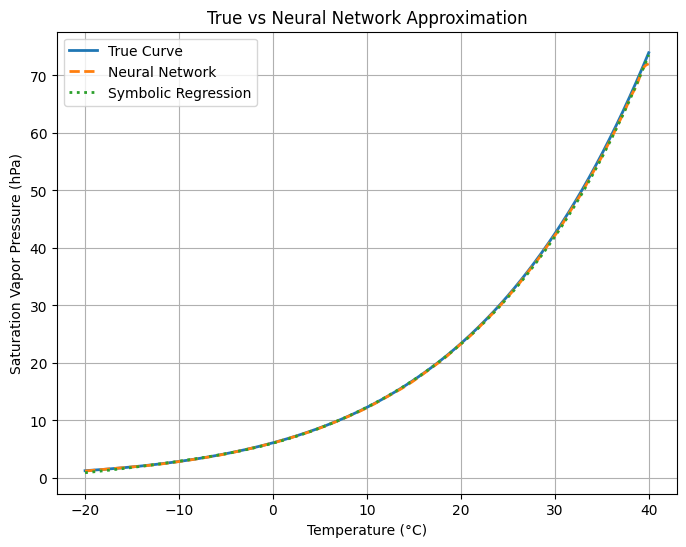

In [97]:
y_plot_sr = f(x_plot)

plt.figure(figsize=(8,6))

plt.plot(
    x_plot.numpy(),
    y_true_plot.numpy(),
    label="True Curve",
    linewidth=2
)

plt.plot(
    x_plot.numpy(),
    y_pred_plot.numpy(),
    label="Neural Network",
    linestyle="--",
    linewidth=2
)

plt.plot(
    x_plot.numpy(),
    y_plot_sr,
    label="Symbolic Regression",
    linestyle=":",
    linewidth=2
)

plt.xlabel("Temperature (°C)")
plt.ylabel("Saturation Vapor Pressure (hPa)")
plt.title("True vs Neural Network Approximation")
plt.legend()
plt.grid(True)

plt.show()